# Anchor Patch 索引预生成调试 Notebook

基于 `reg_tool/core.py` 中 `anchor_patch` 分支（约第 391-486 行）拆分为可逐步调试的流程。

目标：
- 在训练前预生成训练/推理索引二维数组
- 核对每一步 shape、索引范围、落盘结果
- 不做 mask，保留到 `dataset` 中处理

In [1]:
import os
from pathlib import Path

import numpy as np
from h5py import File


from matplotlib import pyplot as plt

from patch_sampler import (
    normalize_coords,
    precompute_train_patches_2d,
    precompute_infer_patches_4d,
    make_grid_blocks_from_shape_4d
)

np.set_printoptions(precision=4, suppress=True)
print('Imports OK')

Imports OK


In [2]:
# ====== 1) 参数区（可按需修改） ======
base_dir = '../h5/dongfang'
patch_dir = os.path.join(base_dir, 'patchV2')
os.makedirs(patch_dir, exist_ok=True)

info_h5_raw = os.path.join(base_dir, 'raw5d_data1104.h5')
info_h5_regular = os.path.join(base_dir, 'reg5dbin_label1031.h5')
info_h5_target = os.path.join(base_dir, 'reg5dbin_label1031.h5')
with File(info_h5_regular, 'r') as f_target:
    info_f_target = f_target['1551']
    print(list(info_f_target.keys()))
    mask = info_f_target['mask'][:]
group_key = '1551'
trusted_mask_key = mask 
print(mask.sum())
print(mask.shape)
print(mask[:10])
query_mask_key = mask.astype(bool)
print(query_mask_key[:10])
# 例如 'mask'；若为 None 则 trusted=全部 obs



['cmp', 'cmp_line', 'data', 'delta', 'mask', 'offset', 'recv_line', 'recv_no', 'recv_stake', 'rx', 'ry', 'shot_line', 'shot_no', 'shot_stake', 'sx', 'sy', 't0', 'trace_idx']
841791
(1825790,)
[1 0 1 0 1 1 1 1 1 0]
[ True False  True False  True  True  True  True  True False]


In [3]:
# ====== 2) 读取 H5 基础字段 ======
with File(info_h5_raw, 'r') as f_raw, File(info_h5_regular, 'r') as f_reg:
    info_f_raw = f_raw[group_key]
    info_f_regular = f_reg[group_key]

    print('raw keys    :', list(info_f_raw.keys()))
    print('regular keys:', list(info_f_regular.keys()))

    trace_obs = info_f_raw['data'][:]
    coord_obs = np.column_stack([
        info_f_raw['sx'][:],
        info_f_raw['sy'][:],
        info_f_raw['rx'][:],
        info_f_raw['ry'][:],
    ]).astype(np.float32)

    coord_grid = np.column_stack([
        info_f_regular['sx'][:],
        info_f_regular['sy'][:],
        info_f_regular['rx'][:],
        info_f_regular['ry'][:],
    ]).astype(np.float32)
    
    nsx =len(np.unique(info_f_regular['sx']))
    nsy =len(np.unique(info_f_regular['sy']))
    nrx =len(np.unique(info_f_regular['rx']))
    nry =len(np.unique(info_f_regular['ry']))

print('trace_obs shape:', trace_obs.shape)
print('coord_obs shape:', coord_obs.shape)
print('coord_grid shape:', coord_grid.shape)
assert trace_obs.shape[0] == coord_obs.shape[0]

raw keys    : ['cmp', 'cmp_line', 'data', 'delta', 'offset', 'recv_line', 'recv_no', 'recv_stake', 'rx', 'ry', 'shot_line', 'shot_no', 'shot_stake', 'sx', 'sy', 't0', 'trace_idx']
regular keys: ['cmp', 'cmp_line', 'data', 'delta', 'mask', 'offset', 'recv_line', 'recv_no', 'recv_stake', 'rx', 'ry', 'shot_line', 'shot_no', 'shot_stake', 'sx', 'sy', 't0', 'trace_idx']
trace_obs shape: (1010972, 1251)
coord_obs shape: (1010972, 4)
coord_grid shape: (1825790, 4)


In [4]:
# ====== 3) trusted：与 raw 行序 1:1 对齐 ======
# raw_obs_valid[i]==True ⟺ raw 第 i 道的四维键落在「规则网格 mask 为 True 的格点键集合」里。
# 与 coord_obs[i]、trace_obs[i]、H5 raw 第 i 行一致。precompute_infer_patches_4d(..., obs_valid_mask=raw_obs_valid)。
# trusted_row_indices = flatnonzero(raw_obs_valid)，即 raw 全局行号，与下标语义一致。

from core import generate_binning_keys, raw_obs_valid_mask_from_regular_trusted_mask

regular_trusted_mask = np.asarray(mask).reshape(-1).astype(bool)

with File(info_h5_raw, 'r') as f_raw, File(info_h5_regular, 'r') as f_reg:
    raw_g = f_raw[group_key]
    reg_g = f_reg[group_key]
    raw_keys = generate_binning_keys(raw_g).astype(np.int64)
    reg_keys = generate_binning_keys(reg_g).astype(np.int64)

if regular_trusted_mask.size != reg_keys.shape[0]:
    raise ValueError(
        f'mask length ({regular_trusted_mask.size}) != regular trace count ({reg_keys.shape[0]})'
    )

raw_obs_valid = raw_obs_valid_mask_from_regular_trusted_mask(
    raw_binning_keys=raw_keys,
    reg_binning_keys=reg_keys,
    regular_trusted_mask=regular_trusted_mask,
)

assert raw_obs_valid.shape[0] == coord_obs.shape[0] == trace_obs.shape[0], (
    'raw_obs_valid 须与 coord_obs / trace_obs 行数一致'
)

trusted_row_indices = np.flatnonzero(raw_obs_valid).astype(np.int64)

print('regular mask sum:', int(regular_trusted_mask.sum()))
print('regular trace count:', reg_keys.shape[0])
print('raw trace count:', raw_keys.shape[0])
print('raw_obs_valid True count:', int(raw_obs_valid.sum()))
print(raw_obs_valid.shape)
print('trusted_row_indices len:', trusted_row_indices.size)
if trusted_row_indices.size > 0:
    print('trusted_row_indices min/max:', trusted_row_indices.min(), trusted_row_indices.max())
assert np.array_equal(trusted_row_indices, np.flatnonzero(raw_obs_valid))


regular mask sum: 841791
regular trace count: 1825790
raw trace count: 1010972
raw_obs_valid True count: 1010529
(1010972,)
trusted_row_indices len: 1010529
trusted_row_indices min/max: 6 1010969


In [9]:
# 采样参数
num_anchors = trace_obs.shape[0]//128
print(num_anchors)
k_patch = 256
top_l = 256+128
num_query = 8
beta = 0.3
seed = 0
metric_weights = [1.0, 1.0, 0.5, 0.5]



print('patch_dir =', patch_dir)

7898
patch_dir = ../h5/dongfang/patchV2


In [6]:
# ====== 4) 坐标归一化 + 统计保存 ======
coord_obs_norm, coord_grid_norm, norm_stats = normalize_coords(coord_obs, coord_grid)

norm_stats_flat = {
    'obs_min': norm_stats['obs']['min'],
    'obs_max': norm_stats['obs']['max'],
    'obs_mean': norm_stats['obs']['mean'],
    'obs_std': norm_stats['obs']['std'],
    'grid_min': norm_stats['grid']['min'],
    'grid_max': norm_stats['grid']['max'],
    'grid_mean': norm_stats['grid']['mean'],
    'grid_std': norm_stats['grid']['std'],
}

coord_stat_path = os.path.join(patch_dir, 'coord_norm_stats.npz')
coord_obs_norm_path = os.path.join(patch_dir, 'coord_obs_norm.npy')
coord_grid_norm_path = os.path.join(patch_dir, 'coord_grid_norm.npy')
np.savez(coord_stat_path, **norm_stats_flat)
np.save(coord_obs_norm_path, coord_obs_norm)
np.save(coord_grid_norm_path, coord_grid_norm)


print('coord_obs_norm range:', coord_obs_norm.min(), coord_obs_norm.max())
print('coord_grid_norm range:', coord_grid_norm.min(), coord_grid_norm.max())
print('saved:', coord_stat_path)

coord_obs_norm range: -1.0 1.0
coord_grid_norm range: -1.0 1.0
saved: ../h5/dongfang/patchV2/coord_norm_stats.npz


In [7]:
def build_grid_index_map_4d_from_coord_grid(
    coord_grid,
    *,
    on_collision: str = "raise",
):
    """从 ``coord_grid`` 构造 ``grid_index_map_4d``，供 ``precompute_infer_patches_4d(..., grid_index_map_4d=...)`` 使用。

    约定
    ----
    - ``coord_grid`` 形状 ``(N, 4)``，列顺序 ``[sx, sy, rx, ry]``（物理坐标即可），行顺序必须与
      ``coord_grid_norm`` **完全一致**（第 ``i`` 行对应同一条网格道）。
    - 每一列单独 ``np.unique`` 得到该轴排序后的刻度；第 ``i`` 行的四维逻辑下标为
      ``(inv_sx[i], inv_sy[i], inv_rx[i], inv_ry[i])``。
    - 逻辑张量形状为 ``(nsx, nsy, nrx, nry)``，其中 ``nsx=len(unique(sx))`` 等，与 notebook 里
      ``len(np.unique(sx))`` 一致；**不要求** ``N == nsx*nsy*nrx*nry``，空位填 ``-1``。

    参数
    ----
    on_collision : ``"raise"`` | ``"last"``
        若多条 ``coord_grid`` 行落在同一四维格点：``raise`` 报错；``last`` 保留行号较大者。

    返回
    ----
    grid_index_map_4d : ndarray, int64, shape ``(nsx, nsy, nrx, nry)``
        有数据处为 ``coord_grid`` 行号（即 ``coord_grid_norm`` 行号），无数据为 ``-1``。
    info : dict
        ``sx_levels, sy_levels, rx_levels, ry_levels`` 与 ``nsx, nsy, nrx, nry``。
    """
    g = np.asarray(coord_grid, dtype=np.float64)
    if g.ndim != 2 or g.shape[1] != 4:
        raise ValueError("coord_grid must have shape (N, 4) with columns [sx, sy, rx, ry]")
    n = int(g.shape[0])
    sx_u, inv_sx = np.unique(g[:, 0], return_inverse=True)
    sy_u, inv_sy = np.unique(g[:, 1], return_inverse=True)
    rx_u, inv_rx = np.unique(g[:, 2], return_inverse=True)
    ry_u, inv_ry = np.unique(g[:, 3], return_inverse=True)
    nsx, nsy, nrx, nry = len(sx_u), len(sy_u), len(rx_u), len(ry_u)

    lin = np.ravel_multi_index((inv_sx, inv_sy, inv_rx, inv_ry), (nsx, nsy, nrx, nry))
    if np.unique(lin).size != n:
        if on_collision == "raise":
            raise ValueError(
                "多条 coord_grid 行映射到同一四维逻辑格；请检查坐标或改用 on_collision='last'"
            )
        if on_collision != "last":
            raise ValueError("on_collision must be 'raise' or 'last'")
        m = np.full((nsx, nsy, nrx, nry), -1, dtype=np.int64)
        for i in range(n):
            m[inv_sx[i], inv_sy[i], inv_rx[i], inv_ry[i]] = np.int64(i)
    else:
        m = np.full((nsx, nsy, nrx, nry), -1, dtype=np.int64)
        m[inv_sx, inv_sy, inv_rx, inv_ry] = np.arange(n, dtype=np.int64)

    info = {
        "sx_levels": sx_u,
        "sy_levels": sy_u,
        "rx_levels": rx_u,
        "ry_levels": ry_u,
        "nsx": nsx,
        "nsy": nsy,
        "nrx": nrx,
        "nry": nry,
    }
    return m, info


# 与 notebook 中 nsx,nsy,nrx,nry 定义一致（可选自检）
grid_index_map_4d, _grid_map_info = build_grid_index_map_4d_from_coord_grid(coord_grid_norm)
print(
    "grid_index_map_4d",
    grid_index_map_4d.shape,
    "有效格点数",
    int(np.sum(grid_index_map_4d >= 0)),
    "coord_grid 行数",
    coord_grid.shape[0],
)
assert int(np.sum(grid_index_map_4d >= 0)) == coord_grid.shape[0], "有效格点数应等于 coord_grid 行数（无重复格点时）"


grid_index_map_4d (36, 189, 35, 11) 有效格点数 1825790 coord_grid 行数 1825790


In [20]:
# ====== 5) 训练二维索引预生成 ======
train_pack = precompute_train_patches_2d(
    coord_obs_norm=coord_obs_norm,
    trace_obs=trace_obs,
    trusted_idx=range(trace_obs.shape[0]),
    num_anchors=num_anchors,
    k_patch=k_patch,
    top_l=top_l,
    metric_weights=metric_weights,
    beta=beta,
    anchor_selector='value_based_anchor_sampling',
    facility_nearest_l=top_l,
    value_local_top_l=top_l,
    value_suppression='subtractive',
    value_suppression_lambda=1.0,
    value_score_tol=0.0,
    value_knn_use_gpu=True,
    value_knn_gpu_batch_rows=512,
    value_knn_gpu_device='cuda:0',
    value_suppression_use_gpu=True,
)

print('anchor_idx shape      :', train_pack['anchor_idx'].shape)
print('patch_idx_2d shape    :', train_pack['patch_idx_2d'].shape)
print('context_idx_2d shape  :', train_pack['context_idx_2d'].shape)
print('query_idx_2d shape    :', train_pack['query_idx_2d'].shape)


building train patches


100%|██████████| 7638/7638 [06:14<00:00, 20.39it/s]


anchor_idx shape      : (7638,)
patch_idx_2d shape    : (7638, 256)
context_idx_2d shape  : (7638, 256)
query_idx_2d shape    : (7638, 0)


In [25]:
# ====== 7) 训练索引落盘 ======
# DatasetH5_all_queryctx._load_patch_metadata 优先匹配:
#   "pool_idx_2d" → train_pool 模式
#   "patch_idx_2d" + train=True → train_pool 模式
# 需要同时保存 anchor_idx 供 _build_train_query_context_sample 使用。

# 方案 A：保存 pool_idx_2d（推荐，_load_patch_metadata 第一优先级）
train_pool_path = os.path.join(patch_dir, 'train_pool_idx_2d.npz')
np.savez(train_pool_path,
    pool_idx_2d=train_pack['patch_idx_2d'],   # (num_patches, K) padded with -1
    anchor_idx=train_pack['anchor_idx'],       # (num_patches,)
)

# 方案 B（兼容）：保存 patch_idx_2d，等价于 pool_idx_2d
'''train_patch_path = os.path.join(patch_dir, 'train_patch_idx_2d.npz')
np.savez(train_patch_path,
    patch_idx_2d=train_pack['patch_idx_2d'],
    anchor_idx=train_pack['anchor_idx'],
)'''

print('train_pack keys:', list(train_pack.keys()))
print('patch_idx_2d  :', train_pack['patch_idx_2d'].shape, train_pack['patch_idx_2d'].dtype)
print('anchor_idx    :', train_pack['anchor_idx'].shape, train_pack['anchor_idx'].dtype)
print('saved training index to:')
print('  ', train_pool_path,  '  ← _load_patch_metadata → train_pool (pool_idx_2d)')
#print('  ', train_patch_path, '  ← _load_patch_metadata → train_pool (patch_idx_2d+train)')

train_pack keys: ['anchor_idx', 'anchor_coord', 'patch_idx_2d', 'pool_idx_2d', 'context_idx_2d', 'query_idx_2d']
patch_idx_2d  : (7638, 256) int64
anchor_idx    : (7638,) int64
saved training index to:
   ../h5/dongfang/patchV2/train_pool_idx_2d.npz   ← _load_patch_metadata → train_pool (pool_idx_2d)


In [8]:
block_size =(nsx//6, nsy//21, nrx//7, nry//5)
stride = (nsx//6, nsy//21, nrx//7, nry//5)
print(block_size, stride)
print(nsx, nsy, nrx, nry)

(6, 9, 5, 2) (6, 9, 5, 2)
36 189 35 11


In [9]:
blocks =  make_grid_blocks_from_shape_4d(nsx, nsy, nrx, nry, block_size, stride)
print(len(blocks))

5292


In [10]:
infer_pack = precompute_infer_patches_4d(
    coord_obs_norm=coord_obs_norm,
    coord_grid_norm=coord_grid_norm,
    grid_shape_4d=None,
    block_size=block_size,
    stride=stride,
    k_patch=k_patch,
    top_l=k_patch * 2,
    require_full_query_coverage=True,
    grid_query_mask=query_mask_key,
    grid_index_map_4d=grid_index_map_4d,
    max_query_per_patch=64,
    obs_valid_mask=None,
    gpu_query_chunk_size=64,
    gpu_device='cuda:0',
)

# 当前语义：每个样本 = query 集合 + 各 query 独立找出的 context 并集
query_idx_list = infer_pack["grid_query_idx_list"]
context_idx_list = infer_pack["patch_idx_list"]
anchor_idx_list = infer_pack["anchor_grid_idx_list"]
context_idx_per_anchor_list = infer_pack["context_idx_per_anchor_list"]

[precompute_infer_patches_4d] build context selector
[precompute_infer_patches_4d] build 4D blocks


prepare 4d blocks: 100%|██████████| 4368/4368 [00:00<00:00, 36140.18it/s]


[precompute_infer_patches_4d] prepared query chunks: blocks=4368 query_slots=934655 estimated_patches=16688 queries_per_patch=64 context_size=256


assemble infer patches: 100%|██████████| 4368/4368 [02:07<00:00, 34.18it/s]


[precompute_infer_patches_4d] patches=16688 query_slots=934655 unique_query_indices=841791 duplicate_rate=0.099356 missing_grid=841791 covered_unique=841791/841791
[precompute_infer_patches_4d] per-patch Q: min=1 max=64 mean=56.0076 | Kctx: min=256 max=256 mean=256.0000 | Q/(Q+Kctx): min=0.003891 max=0.200000 mean=0.179154 p50=0.179487 p5=0.155116 p95=0.197492


query count min/max/mean: 1 64 56.007610258868645
input count min/max/mean: 257 320 312.0076102588686
query+context missing ratio min/max/mean: 0.0038910506 0.2 0.17915377


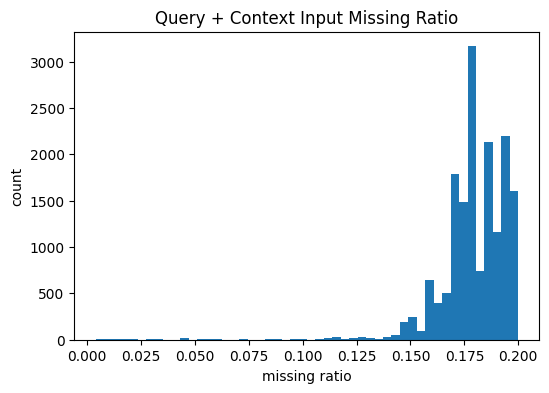

In [11]:
# ====== 从 list-based 输出构造 padded 2D 数组（与 _build_infer_precompute_output include_padded=True 对齐） ======
# query+context 输入缺失率统计
query_context_mask_list = []
input_missing_ratio = np.zeros((len(query_idx_list),), dtype=np.float32)
for i, (q_idx, c_idx) in enumerate(zip(query_idx_list, context_idx_list)):
    query_mask = np.zeros((len(q_idx),), dtype=bool)
    context_mask = np.ones((len(c_idx),), dtype=bool)
    input_mask = np.concatenate([query_mask, context_mask], axis=0)
    query_context_mask_list.append(input_mask)
    input_missing_ratio[i] = 1.0 - input_mask.mean() if input_mask.size > 0 else 0.0

infer_pack["query_context_mask_list"] = query_context_mask_list
infer_pack["input_missing_ratio"] = input_missing_ratio

#print("context-only valid ratio min/max:", infer_pack["patch_mask_2d"].mean(axis=-1).min(), infer_pack["patch_mask_2d"].mean(axis=-1).max())
print("query count min/max/mean:", infer_pack["patch_query_count"].min(), infer_pack["patch_query_count"].max(), infer_pack["patch_query_count"].mean())
#print("context count min/max/mean:", infer_pack["patch_context_count"].min(), infer_pack["patch_context_count"].max(), infer_pack["patch_context_count"].mean())
print("input count min/max/mean:", infer_pack["patch_input_count"].min(), infer_pack["patch_input_count"].max(), infer_pack["patch_input_count"].mean())
print("query+context missing ratio min/max/mean:", input_missing_ratio.min(), input_missing_ratio.max(), input_missing_ratio.mean())

plt.figure(figsize=(6, 4))
plt.hist(input_missing_ratio, bins=50)
plt.title("Query + Context Input Missing Ratio")
plt.xlabel("missing ratio")
plt.ylabel("count")
plt.show()


/tmp/ipykernel_3695844/3754806497.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/chengzhitong/.conda/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chengzhitong/.conda/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chengzhitong/.conda/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chengzhitong/.conda/envs/dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED I

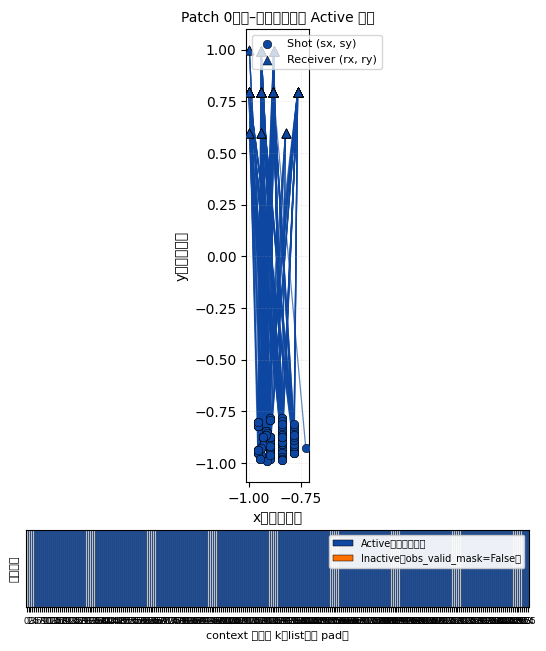

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch


def plot_infer_patch_shot_receiver_pairs(
    infer_pack,
    coord_obs_norm,
    patch_row: int = 0,
    *,
    obs_valid_mask=None,
    figsize=(6.5, 7.5),
    color_present="#0d47a1",
    color_missing="#ff6f00",
    line_alpha=0.65,
    line_width=0.9,
):
    """单个 patch：炮点 (sx,sy) 与检波点 (rx,ry) 同平面展示，连线表示道对。

    无 pad 模式：使用 ``infer_pack['patch_idx_list']`` 或 ``context_idx_list``（与
    ``precompute_infer_patches_4d(..., include_padded=False)`` 一致）。可选 ``obs_valid_mask``
    标出「下标在池中但观测无效」的槽位（语义上类似旧版 padding 槽：主图不画、条带标橙）。

    若存在 ``patch_idx_2d`` + ``patch_mask_2d``，仍按定长槽位 + padding 解析（向后兼容）。
    """
    coord_obs_norm = np.asarray(coord_obs_norm, dtype=np.float64)
    n_obs = int(coord_obs_norm.shape[0])

    if "patch_idx_2d" in infer_pack and "patch_mask_2d" in infer_pack:
        pidx = np.asarray(infer_pack["patch_idx_2d"][patch_row], dtype=np.int64).reshape(-1)
        valid = (np.asarray(infer_pack["patch_mask_2d"][patch_row]) > 0) & (pidx >= 0)
        strip_xlabel = "slot index k（含 padding）"
        inactive_legend = "Inactive（padding / mask）"
    elif "patch_idx_list" in infer_pack:
        pidx = np.asarray(infer_pack["patch_idx_list"][patch_row], dtype=np.int64).reshape(-1)
        if obs_valid_mask is not None:
            ovm = np.asarray(obs_valid_mask, dtype=bool).reshape(-1)
            if ovm.shape[0] != n_obs:
                raise ValueError(f"obs_valid_mask 长度 {ovm.shape[0]} 与 coord_obs_norm {n_obs} 不一致")
            valid = ovm[pidx]
        else:
            valid = np.ones((pidx.size,), dtype=bool)
        strip_xlabel = "context 道序号 k（list，无 pad）"
        inactive_legend = "Inactive（obs_valid_mask=False）"
    elif "context_idx_list" in infer_pack:
        pidx = np.asarray(infer_pack["context_idx_list"][patch_row], dtype=np.int64).reshape(-1)
        if obs_valid_mask is not None:
            ovm = np.asarray(obs_valid_mask, dtype=bool).reshape(-1)
            if ovm.shape[0] != n_obs:
                raise ValueError(f"obs_valid_mask 长度 {ovm.shape[0]} 与 coord_obs_norm {n_obs} 不一致")
            valid = ovm[pidx]
        else:
            valid = np.ones((pidx.size,), dtype=bool)
        strip_xlabel = "context 道序号 k（list，无 pad）"
        inactive_legend = "Inactive（obs_valid_mask=False）"
    else:
        raise KeyError(
            "infer_pack 需包含 patch_idx_list 或 context_idx_list；"
            "或同时包含 patch_idx_2d 与 patch_mask_2d"
        )

    K = int(pidx.size)
    pc = np.full((K, 4), np.nan, dtype=np.float64)
    for k in range(K):
        ik = int(pidx[k])
        if ik < 0 or ik >= n_obs:
            valid[k] = False
            continue
        pc[k] = coord_obs_norm[ik]

    active = valid & np.isfinite(pc).all(axis=1)
    inactive = ~active

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[5, 0.85], hspace=0.18)
    ax = fig.add_subplot(gs[0])
    ax_strip = fig.add_subplot(gs[1])

    if np.any(active):
        for k in range(K):
            if not active[k]:
                continue
            ax.plot(
                [pc[k, 0], pc[k, 2]],
                [pc[k, 1], pc[k, 3]],
                color=color_present,
                linewidth=line_width,
                alpha=line_alpha,
                solid_capstyle="round",
                zorder=1,
            )
        ax.scatter(
            pc[active, 0],
            pc[active, 1],
            c=color_present,
            s=38,
            marker="o",
            edgecolors="k",
            linewidths=0.35,
            label="Shot (sx, sy)",
            zorder=3,
        )
        ax.scatter(
            pc[active, 2],
            pc[active, 3],
            c=color_present,
            s=42,
            marker="^",
            edgecolors="k",
            linewidths=0.35,
            label="Receiver (rx, ry)",
            zorder=3,
        )
    else:
        ax.text(0.5, 0.5, "no valid traces", ha="center", va="center", transform=ax.transAxes)

    for k in range(K):
        c = color_present if active[k] else color_missing
        ax_strip.bar(k, 1, width=0.92, color=c, edgecolor="0.35", linewidth=0.3, align="center")
    ax_strip.set_xlim(-0.5, max(K - 0.5, 0.5))
    ax_strip.set_ylim(0, 1)
    if K > 0:
        ax_strip.set_xticks(np.arange(K))
    ax_strip.set_yticks([])
    ax_strip.tick_params(axis="x", labelsize=6)
    ax_strip.set_xlabel(strip_xlabel, fontsize=8)
    ax_strip.set_ylabel("槽位状态", rotation=90, fontsize=8)

    leg_handles = [
        Patch(facecolor=color_present, edgecolor="k", linewidth=0.35, label="Active（参与主图）"),
        Patch(facecolor=color_missing, edgecolor="k", linewidth=0.35, label=inactive_legend),
    ]
    ax_strip.legend(handles=leg_handles, loc="upper right", fontsize=7, ncol=1, framealpha=0.92)

    ttl = f"Patch {patch_row}：炮–检对（主图仅 Active 道）"
    if inactive.any():
        ttl += f" — {int(inactive.sum())} 个 Inactive 槽位"
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("x（归一化）")
    ax.set_ylabel("y（归一化）")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.5)
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()


# 若前面单元格定义了 obs_valid_mask，会自动传入以标出无效观测道；否则 list 模式下默认全部 Active
plot_infer_patch_shot_receiver_pairs(
    infer_pack,
    coord_obs_norm,
    patch_row=0,
    obs_valid_mask=globals().get("obs_valid_mask"),
)


In [13]:
# ====== 推理索引落盘 ======
# DatasetH5_all_queryctx._load_patch_metadata 优先匹配:
#   "grid_query_idx_list" + "context_idx_list" → infer_query_context 模式

# query+context list 格式（_load_patch_metadata 优先匹配此格式）
#    query 来自 h5_data_regular（规则网格），context 来自 h5_data（原始观测）
infer_query_context_path = os.path.join(patch_dir, 'infer_query_context.npz')
np.savez(
    infer_query_context_path,
    grid_query_idx_list=np.array(infer_pack["grid_query_idx_list"], dtype=object),
    context_idx_list=np.array(infer_pack["patch_idx_list"], dtype=object),
    block_id=infer_pack["block_id"],
    block_center_grid_idx=infer_pack["block_center_grid_idx"],
    anchor_grid_idx_list=np.array(infer_pack["anchor_grid_idx_list"], dtype=object),
)

# legacy 兼容格式（给 DatasetH5_all 或其他脚本使用）
#np.savez(os.path.join(patch_dir, 'infer_patch_idx_2d.npz'), **{'0': infer_pack['patch_idx_2d']})
#np.savez(os.path.join(patch_dir, 'infer_patch_mask_2d.npz'), **{'0': infer_pack['patch_mask_2d']})
#np.save(os.path.join(patch_dir, 'infer_block_id.npy'), infer_pack['block_id'])
#np.save(os.path.join(patch_dir, 'infer_block_center_grid_idx.npy'), infer_pack['block_center_grid_idx'])

print('infer_query_context.npz:')
print('  grid_query_idx_list:', len(infer_pack["grid_query_idx_list"]), 'patches')
print('  context_idx_list   :', len(infer_pack["patch_idx_list"]), 'patches')
print('  block_id           :', infer_pack['block_id'].shape)
print('  block_center_grid_idx:', infer_pack['block_center_grid_idx'].shape)


infer_query_context.npz:
  grid_query_idx_list: 16688 patches
  context_idx_list   : 16688 patches
  block_id           : (16688,)
  block_center_grid_idx: (16688,)


In [36]:
# ====== 8) 回读检查（保证可被 dataset 直接消费） ======

# --- 训练索引：pool_idx_2d 格式（_load_patch_metadata → train_pool） ---
train_pool_npz = np.load(os.path.join(patch_dir, 'train_pool_idx_2d.npz'), allow_pickle=True)
train_pool_2d = train_pool_npz['pool_idx_2d']
train_anchor_idx = train_pool_npz['anchor_idx']

print('--- training (pool_idx_2d) ---')
print('pool_idx_2d  :', train_pool_2d.shape, train_pool_2d.dtype)
print('anchor_idx   :', train_anchor_idx.shape, train_anchor_idx.dtype)

# 模拟 _load_patch_metadata 的 train_pool 分支
_mock_train = {'pool_idx_2d': train_pool_2d, 'anchor_idx': train_anchor_idx}
assert 'pool_idx_2d' in _mock_train
print(f'_load_patch_metadata 会进入 train_pool 模式, num_samples={train_pool_2d.shape[0]}')

# 模拟 _index_row 取第 0 个 pool
def _index_row(storage, idx):
    """与 DatasetH5_all_queryctx._index_row 语义一致"""
    row = np.asarray(storage[idx], dtype=np.int64).reshape(-1)
    return row[row >= 0]

sample_pool = _index_row(train_pool_2d, 0)
print(f'  sample 0: pool_size={sample_pool.size}, anchor={train_anchor_idx[0]}')
assert sample_pool.size >= 2, "pool must contain at least 2 traces"

# --- 推理索引 — query+context list 格式（_load_patch_metadata 优先匹配） ---
infer_qc = np.load(os.path.join(patch_dir, 'infer_query_context.npz'), allow_pickle=True)
qc_query_list = infer_qc['grid_query_idx_list']
qc_ctx_list   = infer_qc['context_idx_list']
qc_block_id   = infer_qc['block_id']
qc_block_ctr  = infer_qc['block_center_grid_idx']
qc_anchor_list = infer_qc.get('anchor_grid_idx_list', None)

print('\n--- inference query+context list ---')
print('grid_query_idx_list : len=', len(qc_query_list), 'dtype=', qc_query_list.dtype)
print('context_idx_list    : len=', len(qc_ctx_list), 'dtype=', qc_ctx_list.dtype)
print('block_id            :', qc_block_id.shape, qc_block_id.dtype)
print('block_center_grid_idx:', qc_block_ctr.shape, qc_block_ctr.dtype)
if qc_anchor_list is not None:
    print('anchor_grid_idx_list: len=', len(qc_anchor_list), 'dtype=', qc_anchor_list.dtype)

# 抽样检查 query+context
assert len(qc_query_list) == len(qc_ctx_list), \
    f"query/context 长度不一致: {len(qc_query_list)} vs {len(qc_ctx_list)}"

num_qc_samples = len(qc_query_list)
check_indices = list(range(min(5, num_qc_samples))) + ([num_qc_samples - 1] if num_qc_samples > 5 else [])
for i in check_indices:
    q = _index_row(qc_query_list, i)
    c = _index_row(qc_ctx_list, i)
    assert q.ndim == 1 and q.dtype == np.int64, f"sample {i}: query not 1D int64"
    assert c.ndim == 1 and c.dtype == np.int64, f"sample {i}: context not 1D int64"
    assert q.size > 0, f"sample {i}: empty query"
    assert c.size > 0, f"sample {i}: empty context"
    print(f'  sample {i}: Q={q.size}, K={c.size}  OK')

# _load_patch_metadata 模拟：确认进入 infer_query_context 模式
_mock_infer = {
    'grid_query_idx_list': qc_query_list,
    'context_idx_list': qc_ctx_list,
    'block_id': qc_block_id,
    'block_center_grid_idx': qc_block_ctr,
}
if qc_anchor_list is not None:
    _mock_infer['anchor_grid_idx_list'] = qc_anchor_list
assert 'grid_query_idx_list' in _mock_infer and 'context_idx_list' in _mock_infer
print(f'\n_load_patch_metadata 会进入 infer_query_context 模式, num_samples={num_qc_samples}')

print('\nAll checks passed.')

--- training (pool_idx_2d) ---
pool_idx_2d  : (7638, 256) int64
anchor_idx   : (7638,) int64
_load_patch_metadata 会进入 train_pool 模式, num_samples=7638
  sample 0: pool_size=256, anchor=918860

--- inference query+context list ---
grid_query_idx_list : len= 60178 dtype= object
context_idx_list    : len= 60178 dtype= object
block_id            : (60178,) int64
block_center_grid_idx: (60178,) int64
anchor_grid_idx_list: len= 60178 dtype= object
  sample 0: Q=16, K=128  OK
  sample 1: Q=16, K=128  OK
  sample 2: Q=15, K=128  OK
  sample 3: Q=15, K=128  OK
  sample 4: Q=15, K=128  OK
  sample 60177: Q=2, K=128  OK

_load_patch_metadata 会进入 infer_query_context 模式, num_samples=60178

All checks passed.
